In [2]:
#Importamos librerías básicas
import pandas as pd # manipulacion dataframes
import numpy as np  # matrices y vectores
import matplotlib.pyplot as plt #gráfica

In [39]:
from scipy.io import arff

# 1. Load the ARFF file using SciPy
data, meta = arff.loadarff("C:/Users/USUARIO/Documents/Codigos/Proyecto e-commerce/data/data.arff")

# 2. Convert it into a Pandas DataFrame
df = pd.DataFrame(data)

df.head()

,customer_state,total_payment_value,total_freight,total_weight_g,total_volume_cm3,principal_category_by_price,principal_seller_state_by_price,purchase_year,facturacion_promedio_t1,facturacion_mediana_t1,...,dias_entrega_promedio_7d_avg,dias_entrega_promedio_t2,dias_entrega_promedio_prev_month,es_post_domingo_festivo,es_diciembre,es_fin_de_semana_extendido,distancia_km,distancia_total_t1,distancia_total_prev_month,delivery_days
0,b'SP',38.71,8.72,500.0,1976.0,b'utilidades_domesticas',b'SP',2017.0,111.890769,91.660,...,10.860524,10.043478,11.886244,1.0,0.0,0.0,18.576110,4025.883311,291113.407386,8.0
1,b'SP',32.70,12.80,200.0,2560.0,b'cama_mesa_banho',b'SP',2018.0,169.101283,112.680,...,7.619223,9.063401,11.552505,0.0,0.0,0.0,309.131371,25226.900324,488209.852444,4.0
2,b'SP',54.36,16.11,583.0,8400.0,b'brinquedos',b'SP',2018.0,146.652034,100.230,...,14.771980,15.841772,14.586934,0.0,0.0,0.0,430.144201,21694.682189,421109.470293,11.0
3,b'SP',29.75,11.85,250.0,4800.0,b'cama_mesa_banho',b'SP',2017.0,170.919272,117.600,...,12.902686,12.000000,11.846389,0.0,0.0,0.0,209.757656,9623.066166,343516.704227,6.0
4,b'SP',118.86,8.96,525.0,4368.0,b'beleza_saude',b'SP',2017.0,219.488889,106.805,...,11.561738,10.369565,11.021440,1.0,0.0,0.0,11.680956,6110.978959,304388.330097,21.0


In [40]:
umbral = df["distancia_km"].quantile(0.985)
df = df[df["distancia_km"] <= umbral].reset_index(drop=True)

df = df[df["distancia_km"] > 4].reset_index(drop=True)

In [4]:
df.columns 

Index(['customer_state', 'total_payment_value', 'total_freight',
       'total_weight_g', 'total_volume_cm3', 'principal_category_by_price',
       'principal_seller_state_by_price', 'purchase_year',
       'facturacion_promedio_t1', 'facturacion_mediana_t1',
       'facturacion_std_t1', 'facturacion_total_7d_avg',
       'dias_entrega_promedio_7d_avg', 'dias_entrega_promedio_t2',
       'dias_entrega_promedio_prev_month', 'es_post_domingo_festivo',
       'es_diciembre', 'es_fin_de_semana_extendido', 'distancia_km',
       'distancia_total_t1', 'distancia_total_prev_month', 'delivery_days'],
      dtype='object')

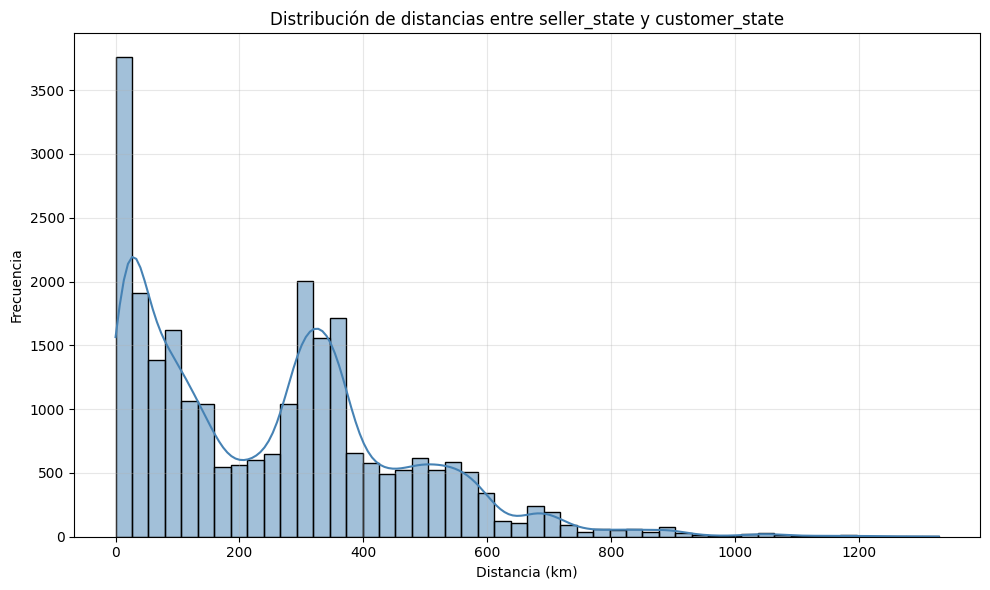

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['distancia_km'].dropna(), bins=50, kde=True, color='steelblue')
plt.title('Distribución de distancias entre seller_state y customer_state')
plt.xlabel('Distancia (km)')
plt.ylabel('Frecuencia')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [41]:
#Correccion de tipos de datos
df['customer_state']=df['customer_state'].astype('category')
df["principal_category_by_price"] = df["principal_category_by_price"].astype('category')
df["principal_seller_state_by_price"] = df["principal_seller_state_by_price"].astype('category')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24916 entries, 0 to 24915
Data columns (total 22 columns):
 #   Column                            Non-Null Count  Dtype   
---  ------                            --------------  -----   
 0   customer_state                    24916 non-null  category
 1   total_payment_value               24916 non-null  float64 
 2   total_freight                     24916 non-null  float64 
 3   total_weight_g                    24916 non-null  float64 
 4   total_volume_cm3                  24916 non-null  float64 
 5   principal_category_by_price       24916 non-null  category
 6   principal_seller_state_by_price   24916 non-null  category
 7   purchase_year                     24916 non-null  float64 
 8   facturacion_promedio_t1           24916 non-null  float64 
 9   facturacion_mediana_t1            24916 non-null  float64 
 10  facturacion_std_t1                24916 non-null  float64 
 11  facturacion_total_7d_avg          24916 non-null  floa

In [30]:
print(df['principal_seller_state_by_price'].cat.categories[:5])
print(df['customer_state'].cat.categories[:5])

Index([b'MG', b'PR', b'RJ', b'SP'], dtype='object')
Index([b'RJ', b'SP'], dtype='object')


In [42]:
def decodificar(x):
    return x.decode('utf-8') if isinstance(x, bytes) else x

for col in ['principal_seller_state_by_price', 'customer_state']:
    df[col] = df[col].cat.rename_categories(decodificar)

print(df['principal_seller_state_by_price'].cat.categories)
print(df['customer_state'].cat.categories)

Index(['MG', 'PR', 'RJ', 'SP'], dtype='object')
Index(['RJ', 'SP'], dtype='object')


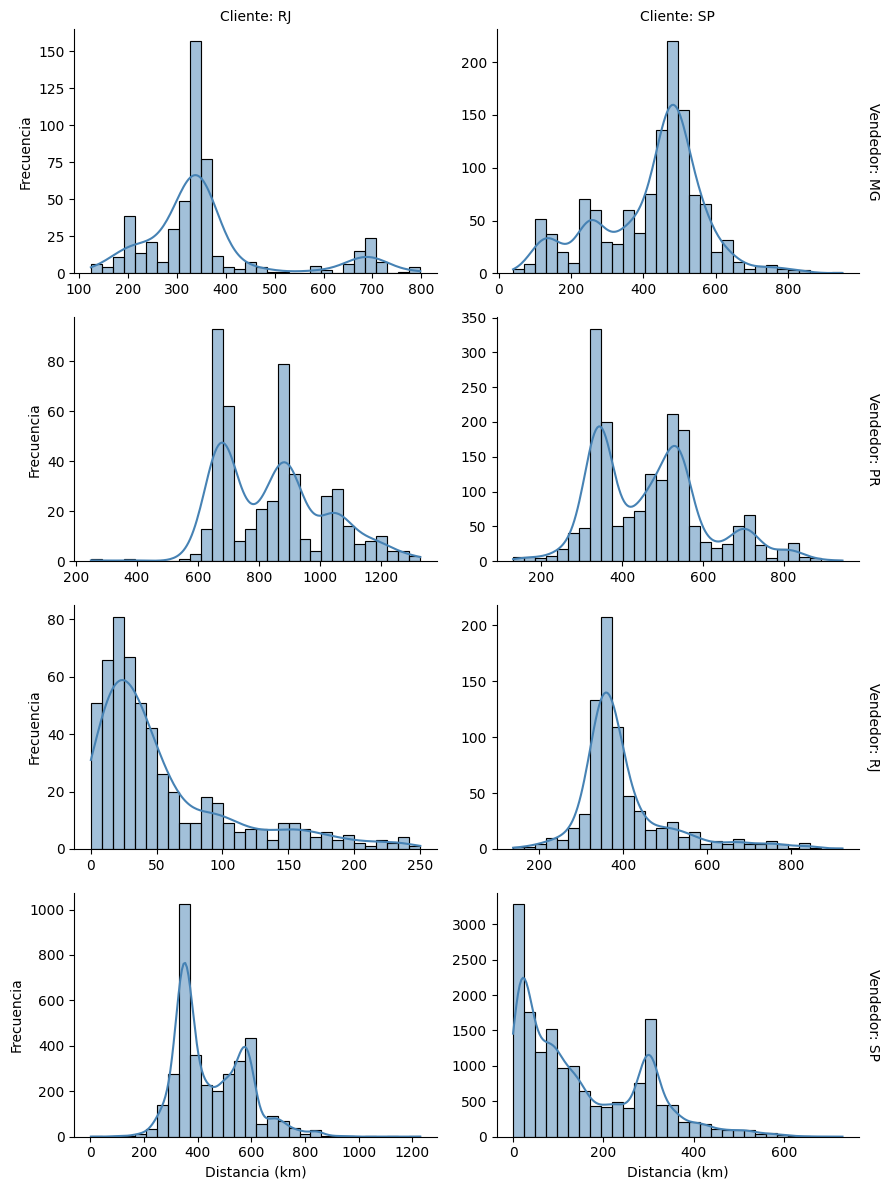

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

df['combo'] = (df['principal_seller_state_by_price'].astype(str) + ' → ' +
               df['customer_state'].astype(str))

g = sns.FacetGrid(df, row='principal_seller_state_by_price', col='customer_state',
                  sharex=False, sharey=False, height=3, aspect=1.5,
                  margin_titles=True)
g.map(sns.histplot, 'distancia_km', bins=30, kde=True, color='steelblue')
g.set_axis_labels('Distancia (km)', 'Frecuencia')
g.set_titles(row_template='Vendedor: {row_name}', col_template='Cliente: {col_name}')
plt.tight_layout()
plt.show()

In [43]:
import pandas as pd

vend = df['principal_seller_state_by_price'].astype(str)
cli = df['customer_state'].astype(str)
df['combo'] = vend + ' → ' + cli
df['mismo_estado'] = vend == cli

# Percentiles por combinación
q_bajo = df.groupby('combo', observed=True)['distancia_km'].transform(lambda s: s.quantile(0.05))
q_alto = df.groupby('combo', observed=True)['distancia_km'].transform(lambda s: s.quantile(0.95))

# Entre estados distintos: quitar el 2% inferior
# Mismo estado: quitar el 2% superior
ok = (
    (~df['mismo_estado'] & (df['distancia_km'] >= q_bajo)) |
    ( df['mismo_estado'] & (df['distancia_km'] <= q_alto))
)

# Distancia 0 nunca es válida (regla que definimos antes)
ok &= (df['distancia_km'] > 2)

df_filtrado = df[ok | df['distancia_km'].isna()].copy()

# Resumen por combinación
antes = df.groupby('combo', observed=True).size()
despues = df_filtrado.groupby('combo', observed=True).size()
print(pd.DataFrame({'antes': antes, 'despues': despues,
                    'eliminados': antes - despues,
                    '%': ((antes - despues) / antes * 100).round(2)}))

         antes  despues  eliminados     %
combo                                    
MG → RJ    514      488          26  5.06
MG → SP   1229     1167          62  5.04
PR → RJ    197      187          10  5.08
PR → SP   1770     1681          89  5.03
RJ → RJ    523      496          27  5.16
RJ → SP    736      699          37  5.03
SP → RJ   3586     3406         180  5.02
SP → SP  16361    15543         818  5.00


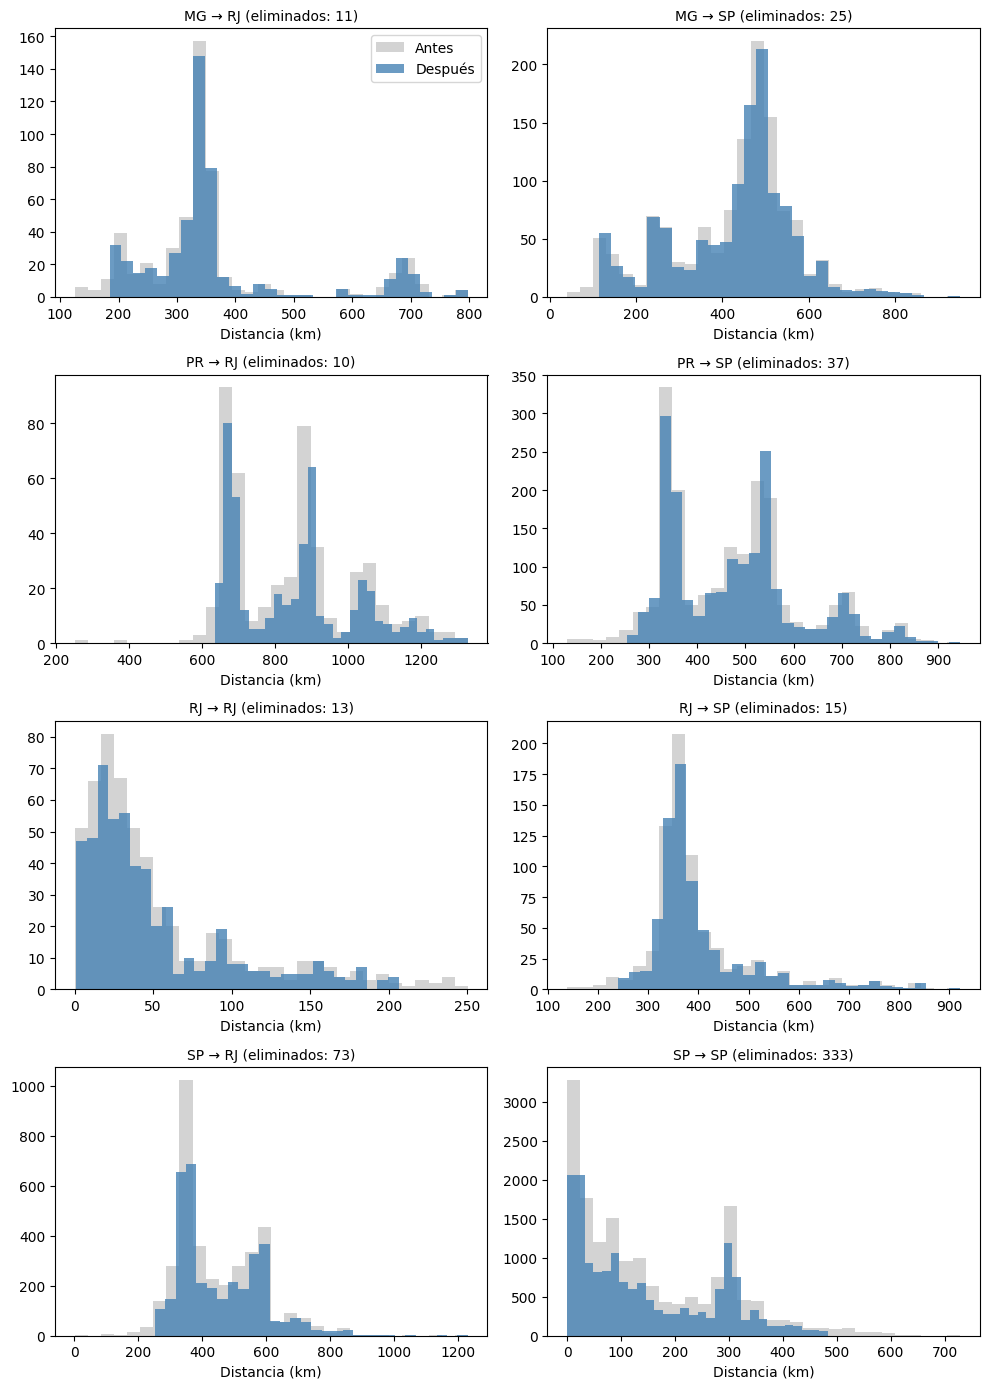

In [23]:
import matplotlib.pyplot as plt

vendedores = ['MG', 'PR', 'RJ', 'SP']
clientes = ['RJ', 'SP']

fig, axes = plt.subplots(4, 2, figsize=(10, 14))
for i, v in enumerate(vendedores):
    for j, c in enumerate(clientes):
        ax = axes[i, j]
        a = df[(df['principal_seller_state_by_price'].astype(str) == v) & (df['customer_state'].astype(str) == c)]
        d = df_filtrado[(df_filtrado['principal_seller_state_by_price'].astype(str) == v) &
                        (df_filtrado['customer_state'].astype(str) == c)]
        ax.hist(a['distancia_km'].dropna(), bins=30, color='lightgray', label='Antes')
        ax.hist(d['distancia_km'].dropna(), bins=30, color='steelblue', alpha=0.8, label='Después')
        ax.set_title(f'{v} → {c} (eliminados: {len(a) - len(d)})', fontsize=10)
        ax.set_xlabel('Distancia (km)')
axes[0, 0].legend()
plt.tight_layout()
plt.show()

In [44]:
print("Columnas:")
print(df_filtrado.columns.tolist())

print(f"\nFilas antes: {len(df):,} | Filas después: {len(df_filtrado):,} "
      f"| Eliminadas: {len(df) - len(df_filtrado):,} "
      f"({(len(df) - len(df_filtrado)) / len(df) * 100:.2f}%)")

df_filtrado.info()
df_filtrado.head(10)

Columnas:
['customer_state', 'total_payment_value', 'total_freight', 'total_weight_g', 'total_volume_cm3', 'principal_category_by_price', 'principal_seller_state_by_price', 'purchase_year', 'facturacion_promedio_t1', 'facturacion_mediana_t1', 'facturacion_std_t1', 'facturacion_total_7d_avg', 'dias_entrega_promedio_7d_avg', 'dias_entrega_promedio_t2', 'dias_entrega_promedio_prev_month', 'es_post_domingo_festivo', 'es_diciembre', 'es_fin_de_semana_extendido', 'distancia_km', 'distancia_total_t1', 'distancia_total_prev_month', 'delivery_days', 'combo', 'mismo_estado']

Filas antes: 24,916 | Filas después: 23,667 | Eliminadas: 1,249 (5.01%)
<class 'pandas.core.frame.DataFrame'>
Index: 23667 entries, 0 to 24915
Data columns (total 24 columns):
 #   Column                            Non-Null Count  Dtype   
---  ------                            --------------  -----   
 0   customer_state                    23667 non-null  category
 1   total_payment_value               23667 non-null  floa

,customer_state,total_payment_value,total_freight,total_weight_g,total_volume_cm3,principal_category_by_price,principal_seller_state_by_price,purchase_year,facturacion_promedio_t1,facturacion_mediana_t1,...,dias_entrega_promedio_prev_month,es_post_domingo_festivo,es_diciembre,es_fin_de_semana_extendido,distancia_km,distancia_total_t1,distancia_total_prev_month,delivery_days,combo,mismo_estado
0,SP,38.71,8.72,500.0,1976.0,b'utilidades_domesticas',SP,2017.0,111.890769,91.660,...,11.886244,1.0,0.0,0.0,18.576110,4025.883311,291113.407386,8.0,SP → SP,True
1,SP,32.70,12.80,200.0,2560.0,b'cama_mesa_banho',SP,2018.0,169.101283,112.680,...,11.552505,0.0,0.0,0.0,309.131371,25226.900324,488209.852444,4.0,SP → SP,True
3,SP,29.75,11.85,250.0,4800.0,b'cama_mesa_banho',SP,2017.0,170.919272,117.600,...,11.846389,0.0,0.0,0.0,209.757656,9623.066166,343516.704227,6.0,SP → SP,True
4,SP,118.86,8.96,525.0,4368.0,b'beleza_saude',SP,2017.0,219.488889,106.805,...,11.021440,1.0,0.0,0.0,11.680956,6110.978959,304388.330097,21.0,SP → SP,True
5,SP,88.90,8.91,250.0,3960.0,b'beleza_saude',SP,2018.0,138.861099,100.485,...,14.586934,0.0,0.0,0.0,13.817425,15249.215838,421109.470293,4.0,SP → SP,True
6,SP,192.68,13.69,292.0,1632.0,b'relogios_presentes',SP,2018.0,142.808909,102.050,...,16.552935,1.0,0.0,0.0,310.592394,8617.038965,471112.176282,14.0,SP → SP,True
7,SP,63.10,14.10,3000.0,8349.0,b'moveis_decoracao',PR,2017.0,154.924854,99.725,...,11.723562,0.0,1.0,0.0,328.060825,31263.421494,343480.138209,22.0,PR → SP,False
8,RJ,100.25,15.35,800.0,19166.0,b'brinquedos',SP,2018.0,166.243536,100.280,...,15.685915,0.0,0.0,1.0,346.123156,15733.527521,350875.393133,18.0,SP → RJ,False
9,SP,43.00,15.10,200.0,2016.0,b'informatica_acessorios',MG,2017.0,120.173333,129.790,...,11.140125,1.0,0.0,0.0,748.532568,3475.184066,204408.639154,7.0,MG → SP,False
10,SP,49.69,12.79,700.0,4800.0,b'cama_mesa_banho',SP,2018.0,211.847647,160.140,...,14.586934,1.0,0.0,0.0,301.251615,7021.780009,421109.470293,10.0,SP → SP,True


In [45]:
import pandas as pd

def resumen(data):
    vend = data['principal_seller_state_by_price'].astype(str)
    cli = data['customer_state'].astype(str)
    combo = vend + ' → ' + cli
    return (data.groupby(combo)['distancia_km']
                .agg(n='count',
                     minimo='min',
                     p25=lambda s: s.quantile(0.25),
                     mediana='median',
                     promedio='mean',
                     p75=lambda s: s.quantile(0.75),
                     maximo='max',
                     desviacion='std')
                .round(1))

stats = resumen(df_filtrado)
stats['cv_%'] = (stats['desviacion'] / stats['promedio'] * 100).round(1)  # variabilidad relativa
print(stats)

             n  minimo    p25  mediana  promedio    p75  maximo  desviacion  \
MG → RJ    488   195.5  314.9    341.8     371.3  356.6   797.7       134.7   
MG → SP   1167   131.0  364.8    468.3     437.0  507.4   794.6       126.2   
PR → RJ    187   634.4  668.7    679.1     686.7  693.5   797.3        33.3   
PR → SP   1681   300.3  351.8    475.5     472.1  541.6   796.9       120.8   
RJ → RJ    496     4.0   18.7     34.0      48.2   60.1   174.0        40.6   
RJ → SP    699   284.5  348.6    370.0     402.8  417.6   790.6        93.8   
SP → RJ   3406   284.7  351.2    415.8     453.3  557.5   797.1       117.3   
SP → SP  15543     4.0   32.0    101.0     139.3  250.3   401.3       115.4   

         cv_%  
MG → RJ  36.3  
MG → SP  28.9  
PR → RJ   4.8  
PR → SP  25.6  
RJ → RJ  84.2  
RJ → SP  23.3  
SP → RJ  25.9  
SP → SP  82.8  


In [46]:
columnas_originales = [
    'customer_state', 'total_payment_value', 'total_freight',
    'total_weight_g', 'total_volume_cm3', 'principal_category_by_price',
    'principal_seller_state_by_price', 'purchase_year',
    'facturacion_promedio_t1', 'facturacion_mediana_t1',
    'facturacion_std_t1', 'facturacion_total_7d_avg',
    'dias_entrega_promedio_7d_avg', 'dias_entrega_promedio_t2',
    'dias_entrega_promedio_prev_month', 'es_post_domingo_festivo',
    'es_diciembre', 'es_fin_de_semana_extendido', 'distancia_km',
    'distancia_total_t1', 'distancia_total_prev_month', 'delivery_days'
]

df_final = df_filtrado[columnas_originales].reset_index(drop=True)

In [47]:
df_final.to_csv('df_final.csv', index=False, encoding='utf-8')

# Para cargarlo después:
df_final = pd.read_csv('df_final.csv')

In [1]:
df_muestra = df_final.sample(frac=0.05, random_state=42)

NameError: name 'df_final' is not defined